# Objective
To analyze movie profitability using production budgets and gross earnings, and uncover ROI trends over time to identify patterns in financial success.

Loading the datasets and importing the libraries

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [16]:
# Load the TN Movie Budgets dataset
df = pd.read_csv("tn.movie_budgets.csv")
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [17]:
# Check for null values
df.isnull().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [18]:
#check for duplicates
df.duplicated().sum()

0

In [19]:
df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


### Data Cleaning

In [20]:
#Clean and Convert Financial Columns to Numeric
# Remove commas and dollar signs
df['production_budget'] = df['production_budget'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['domestic_gross'] = df['domestic_gross'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['worldwide_gross'] = df['worldwide_gross'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [21]:
# Convert 'release_date' to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [22]:
#Check for negative values in the financial columns
negative_values = df[(df['production_budget'] < 0) | 
                     (df['domestic_gross'] < 0) | 
                     (df['worldwide_gross'] < 0)]
negative_values


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross


In [23]:
# Check for missing or NaT values in 'release_date'
missing_dates = df[df['release_date'].isna()]
missing_dates

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross


### ROI Calculation
   We calculate the **ROI (Return on Investment)** for both domestic and worldwide earnings using the formula:
      
      **ROI = (Revenue - Cost) / Cost**
in our case:
Domestic ROI

  **Domestic ROI = (Domestic Gross - Production Budget) / Production Budget**

Worldwide ROI
  
  **Worldwide ROI = (Worldwide Gross - Production Budget) / Production Budget**



   These calculations create two new columns in our dataset: `roi_domestic` and `roi_worldwide`.


In [24]:
 #Calculate ROI
df['roi_domestic'] = (df['domestic_gross'] - df['production_budget']) / df['production_budget']
df['roi_worldwide'] = (df['worldwide_gross'] - df['production_budget']) / df['production_budget']


In [25]:
df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,roi_domestic,roi_worldwide
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,0.789430,5.532577
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,-0.412899,1.546673
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-0.877822,-0.572108
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,0.388403,3.243841
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,0.956408,3.153696


# Exploratory Data Analysis

1.Distribution of Financial Columns

shows how production budgets are distributed across the dataset. Given that budget data is typically right-skewed (a few huge blockbusters vs many lower-budget films), we apply a log scale to better visualize the range.

**Findings**: Most movies have low ROI; a few outliers make massive profits.
Shape: Right-skewed.

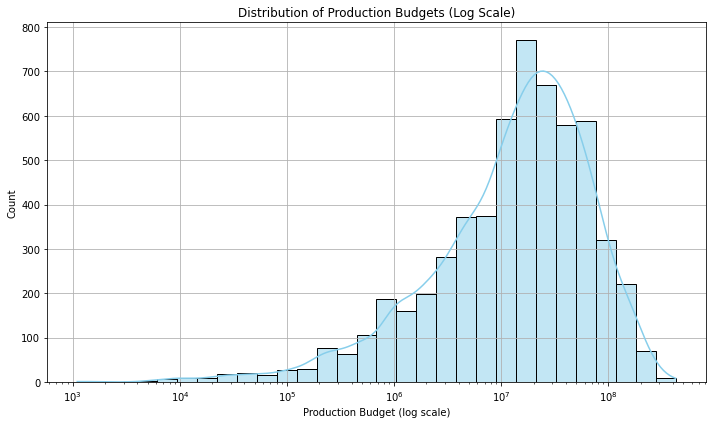

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df['production_budget'], bins=30, kde=True, log_scale=(True, False), color='skyblue')
plt.title('Distribution of Production Budgets (Log Scale)')
plt.xlabel('Production Budget (log scale)')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

2.Production Budget vs ROI (Domestic and Worldwide)
 

To better distinguish the trends, we plot two separate scatter plots: one showing the relationship between production budget and domestic ROI, and another for worldwide ROI. This helps in identifying which market gives a better return for different budget ranges.

**Findings**: No clear upward trend — high budget ≠ high ROI


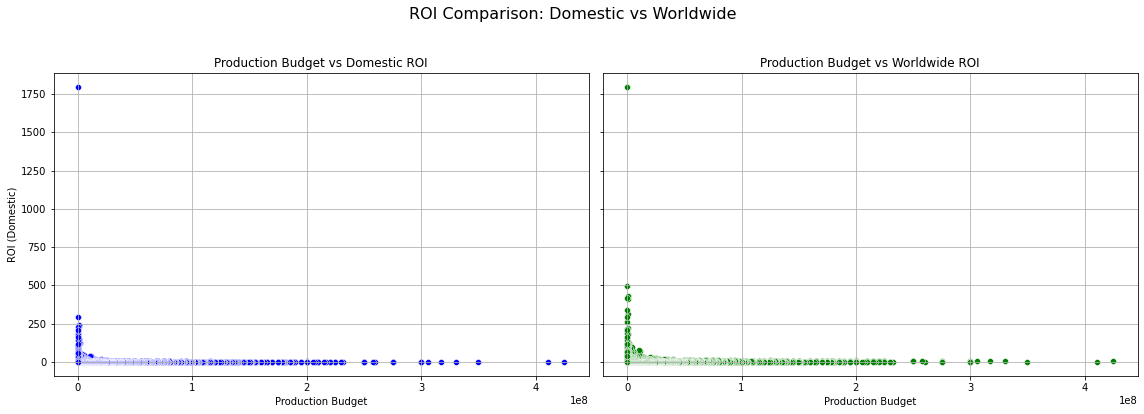

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Domestic ROI plot
sns.scatterplot(ax=axes[0], data=df, x='production_budget', y='roi_domestic', color='blue')
axes[0].set_title('Production Budget vs Domestic ROI')
axes[0].set_xlabel('Production Budget')
axes[0].set_ylabel('ROI (Domestic)')
axes[0].grid(True)

# Worldwide ROI plot
sns.scatterplot(ax=axes[1], data=df, x='production_budget', y='roi_worldwide', color='green')
axes[1].set_title('Production Budget vs Worldwide ROI')
axes[1].set_xlabel('Production Budget')
axes[1].set_ylabel('ROI (Worldwide)')
axes[1].grid(True)

plt.suptitle('ROI Comparison: Domestic vs Worldwide', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




3.ROI Over Time

Track how ROI trends have changed over the years to uncover patterns in profitability across decades.

**Findings:** ROI fluctuates; some years were way more profitable than others.

**Trend:** Industry profit trends shift over time

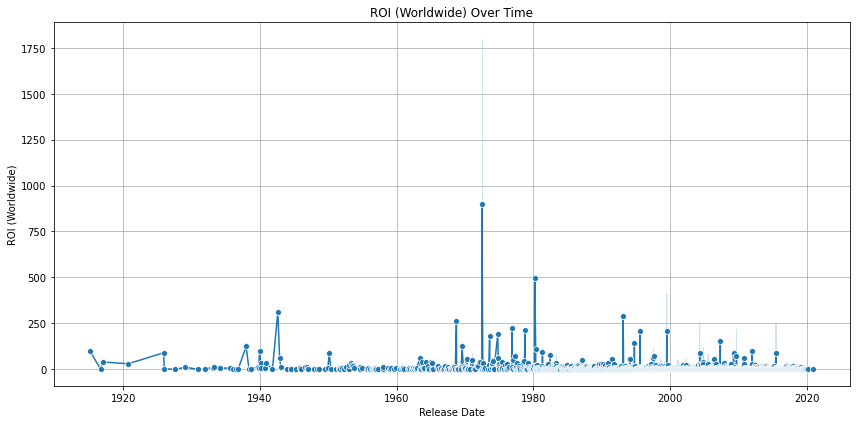

In [28]:
# Convert release_date to datetime if not already
df['release_date'] = pd.to_datetime(df['release_date'])
df_sorted = df.sort_values('release_date')

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sorted, x='release_date', y='roi_worldwide', marker='o')
plt.title('ROI (Worldwide) Over Time')
plt.xlabel('Release Date')
plt.ylabel('ROI (Worldwide)')
plt.grid(True)
plt.tight_layout()
plt.show()


### Hypothesis Testing

To determine whether there's a statistically significant difference in the ROI of **high-budget** versus **low-budget** movies.

**results**
Because the p-value is way less than 0.05, we reject the null hypothesis, meaning there IS a significant difference in ROI between high-budget and low-budget movies.

In [32]:
#Find the median production budget
median_budget = df['production_budget'].median()
#Split the data into high and low budget groups
low_budget = df[df['production_budget'] < median_budget]['roi_worldwide']
high_budget = df[df['production_budget'] >= median_budget]['roi_worldwide']
#Perform two-sample independent t-test
t_stat, p_value = stats.ttest_ind(low_budget, high_budget, equal_var=False)

#Output results
print("T-statistic:", t_stat)
print("P-value:", p_value)
#interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: Significant difference in ROI.")
else:
    print("Fail to reject the null hypothesis: No significant difference in ROI.")


T-statistic: 5.526628707974909
P-value: 3.555173979078268e-08
Reject the null hypothesis: Significant difference in ROI.
